1. Descriptives Stats

Who use more AI?

Major_Category → Weekly_GenAI_Hours
Year_of_Study → Weekly_GenAI_Hours

In [ ]:
import pandas as pd

# Adjust the path if your file is in a different location
df = pd.read_csv('ai_student_impact_dataset.csv')
display(df.head())

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


/tmp/ipykernel_573/1718457716.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Major_Category', y='Weekly_GenAI_Hours', data=avg_genai_by_major, palette='viridis')


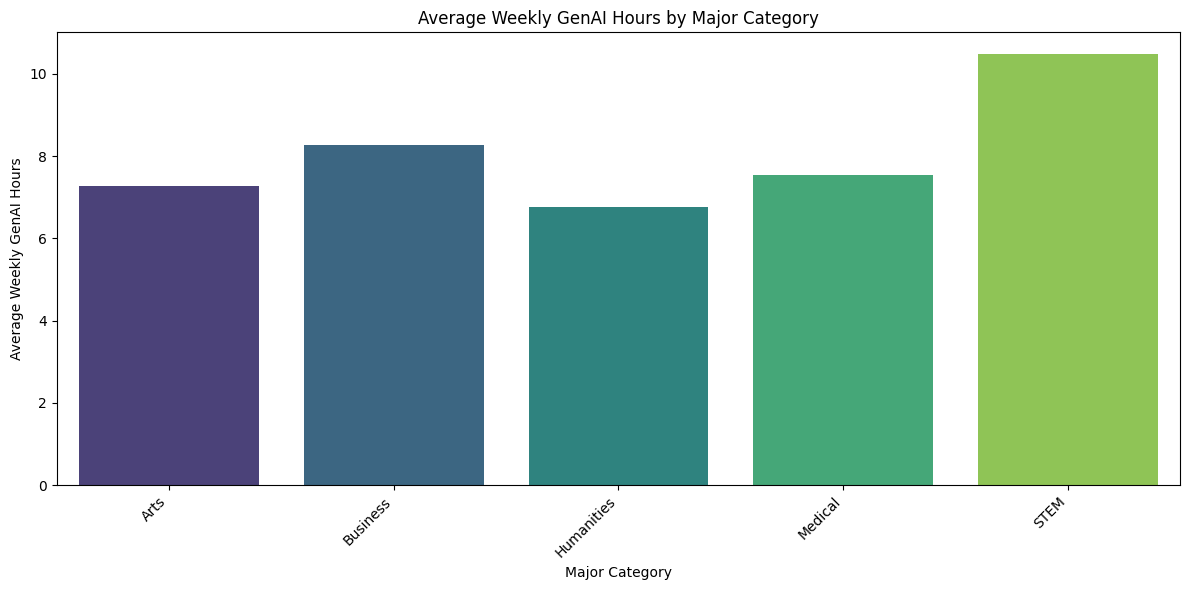

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average Weekly_GenAI_Hours for each Major_Category
avg_genai_by_major = df.groupby('Major_Category')['Weekly_GenAI_Hours'].mean().reset_index()

# Create the bar plot for Major_Category vs Weekly_GenAI_Hours
plt.figure(figsize=(12, 6))
sns.barplot(x='Major_Category', y='Weekly_GenAI_Hours', data=avg_genai_by_major, palette='viridis')
plt.title('Average Weekly GenAI Hours by Major Category')
plt.xlabel('Major Category')
plt.ylabel('Average Weekly GenAI Hours')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

2. Potential positive outcome of AI  on students

['student_id', 'major_category', 'year_of_study', 'pre_semester_gpa', 'weekly_genai_hours', 'primary_use_case', 'prompt_engineering_skill', 'tool_diversity', 'paid_subscription', 'traditional_study_hours', 'perceived_ai_dependency', 'institutional_policy', 'anxiety_level_during_exams', 'post_semester_gpa', 'skill_retention_score', 'burnout_risk_level']

Average anxiety by AI usage group:
ai_group
Low AI Use       3.821912
Medium AI Use    4.004987
High AI Use      4.985838
Name: anxiety_level_during_exams, dtype: float64


/tmp/ipykernel_573/1746157635.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_anxiety = df_analysis.groupby("ai_group")[anxiety_var].mean()


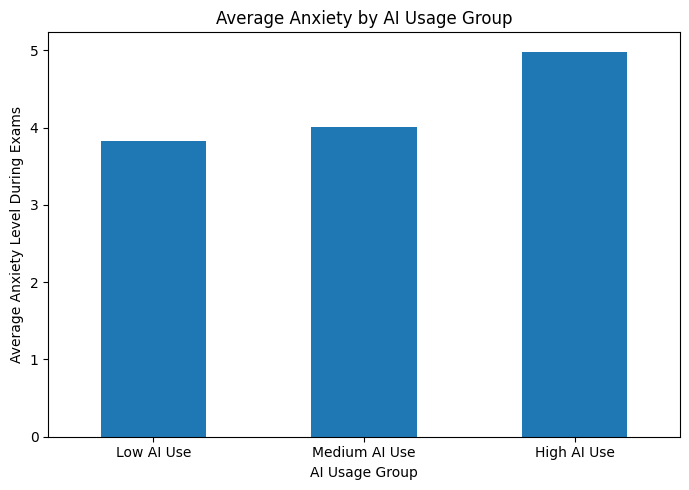


Burnout risk by AI usage group:
burnout_risk_level      High       Low    Medium
ai_group                                        
Low AI Use          0.094405  0.487361  0.418234
Medium AI Use       0.166627  0.363358  0.470016
High AI Use         0.488358  0.131181  0.380461


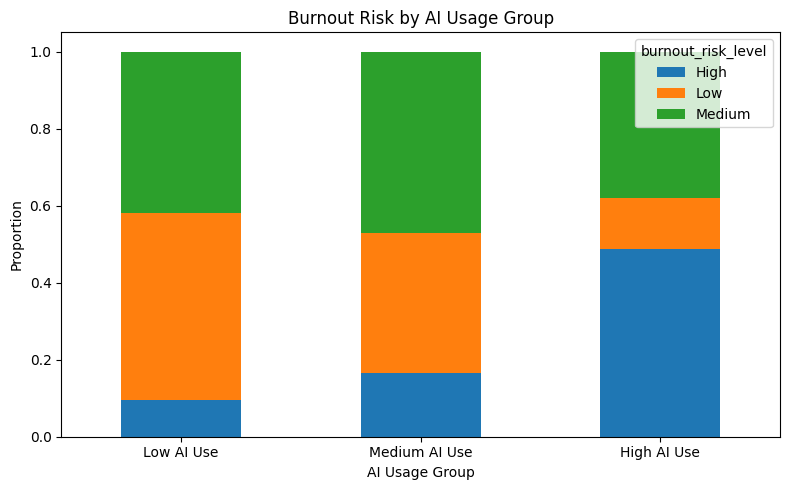


Simple conclusion:
Coefficient of AI usage: 0.0698
P-value: 0.0
Higher AI usage is significantly associated with higher anxiety.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf # Added this import

# Clean column names again
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print(df.columns.tolist())

# Select the actual variable names
ai_var = "weekly_genai_hours"
anxiety_var = "anxiety_level_during_exams"
burnout_var = "burnout_risk_level"

# Keep only the three selected variables
df_analysis = df[[ai_var, anxiety_var, burnout_var]].dropna().copy()

# Convert AI usage hours and anxiety levels to numeric values
df_analysis[ai_var] = pd.to_numeric(df_analysis[ai_var], errors="coerce")
df_analysis[anxiety_var] = pd.to_numeric(df_analysis[anxiety_var], errors="coerce")

df_analysis = df_analysis.dropna()

# 创建 AI 使用分组
df_analysis["ai_group"] = pd.qcut(
    df_analysis[ai_var],
    q=3,
    labels=["Low AI Use", "Medium AI Use", "High AI Use"]
)

# Create AI usage categories based on weekly GenAI hours
mean_anxiety = df_analysis.groupby("ai_group")[anxiety_var].mean()

print("\nAverage anxiety by AI usage group:")
print(mean_anxiety)

# Plot
plt.figure(figsize=(7, 5))
mean_anxiety.plot(kind="bar")
plt.title("Average Anxiety by AI Usage Group")
plt.xlabel("AI Usage Group")
plt.ylabel("Average Anxiety Level During Exams")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



# Burnout
burnout_table = pd.crosstab(
    df_analysis["ai_group"],
    df_analysis[burnout_var],
    normalize="index"
)

print("\nBurnout risk by AI usage group:")
print(burnout_table)

burnout_table.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Burnout Risk by AI Usage Group")
plt.xlabel("AI Usage Group")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Simple conclusion
# Assuming model_anxiety is defined in a previous cell and contains the regression results for anxiety
# If not, you would need to define a regression model here, e.g.:
# import statsmodels.formula.api as smf
model_anxiety = smf.ols(formula=f"{anxiety_var} ~ {ai_var}", data=df_analysis).fit() # Uncommented and now using df_analysis

coef = model_anxiety.params[ai_var]
p_value = model_anxiety.pvalues[ai_var]

print("\nSimple conclusion:")
print("Coefficient of AI usage:", round(coef, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    if coef > 0:
        print("Higher AI usage is significantly associated with higher anxiety.")
    else:
        print("Higher AI usage is significantly associated with lower anxiety.")
else:
    print("There is no strong statistical evidence that AI usage is associated with anxiety.")

In [13]:
import pandas as pd
import statsmodels.formula.api as smf

# Load data
#df = pd.read_csv("../DATA/ai_student_impact_dataset.csv")

# Main regression with controls
formula = """
post_semester_gpa ~ weekly_genai_hours
                  + pre_semester_gpa
                  + C(major_category)
                  + C(year_of_study)
                  + traditional_study_hours
                  + C(prompt_engineering_skill)
                  + tool_diversity
                  + C(paid_subscription)
                  + C(institutional_policy)
"""

model = smf.ols(formula=formula, data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      post_semester_gpa   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                 2.410e+04
Date:                Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:20:38   Log-Likelihood:                 19614.
No. Observations:               50000   AIC:                        -3.919e+04
Df Residuals:                   49982   BIC:                        -3.903e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

3. Potential negative consequences of AI on students

In [14]:
import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_csv("ai_student_impact_dataset.csv")

controls = """
Weekly_GenAI_Hours
+ Pre_Semester_GPA
+ C(Major_Category)
+ C(Year_of_Study)
+ Traditional_Study_Hours
+ C(Prompt_Engineering_Skill)
+ Tool_Diversity
+ C(Paid_Subscription)
+ C(Institutional_Policy)
"""

# 1. Impact on exam anxiety
model_anxiety = smf.ols(
    formula=f"Anxiety_Level_During_Exams ~ {controls}",
    data=df
).fit()



print("Regression 1: AI hours and exam anxiety")
print(model_anxiety.summary())

Regression 1: AI hours and exam anxiety
                                OLS Regression Results                                
Dep. Variable:     Anxiety_Level_During_Exams   R-squared:                       0.093
Model:                                    OLS   Adj. R-squared:                  0.093
Method:                         Least Squares   F-statistic:                     301.7
Date:                        Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                                17:20:53   Log-Likelihood:            -1.0664e+05
No. Observations:                       50000   AIC:                         2.133e+05
Df Residuals:                           49982   BIC:                         2.135e+05
Df Model:                                  17                                         
Covariance Type:                    nonrobust                                         
                                                       coef    std err          t      P>|

In [15]:
#2. Impact on skill retention
model_retention = smf.ols(
    formula=f"Skill_Retention_Score ~ {controls}",
    data=df
).fit()

print("\nRegression 2: AI hours and skill retention")
print(model_retention.summary())


Regression 2: AI hours and skill retention
                              OLS Regression Results                             
Dep. Variable:     Skill_Retention_Score   R-squared:                       0.164
Model:                               OLS   Adj. R-squared:                  0.164
Method:                    Least Squares   F-statistic:                     576.3
Date:                   Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                           17:21:01   Log-Likelihood:            -1.9579e+05
No. Observations:                  50000   AIC:                         3.916e+05
Df Residuals:                      49982   BIC:                         3.918e+05
Df Model:                             17                                         
Covariance Type:               nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------

In [16]:
# 3. Impact on burnout risk
# Convert burnout into ordered numeric variable
df["Burnout_Risk_Num"] = df["Burnout_Risk_Level"].map({
    "Low": 1,
    "Medium": 2,
    "High": 3
})

model_burnout = smf.ols(
    formula=f"Burnout_Risk_Num ~ {controls}",
    data=df
).fit()

print("\nRegression 3: AI hours and burnout risk")
print(model_burnout.summary())


Regression 3: AI hours and burnout risk
                            OLS Regression Results                            
Dep. Variable:       Burnout_Risk_Num   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     1057.
Date:                Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:21:06   Log-Likelihood:                -49267.
No. Observations:               50000   AIC:                         9.857e+04
Df Residuals:                   49982   BIC:                         9.873e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------